In [ ]:
import numpy as np
import xarray as xr
import warnings
from pandas import date_range
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.filter as pcfilter
import pycompo.core.utils as pcutil

import matplotlib.pyplot as plt
import cmocean
import cartopy.crs as ccrs
import cartopy.mpl.ticker as tck
import hfplot.figure.figure as hffig

warnings.filterwarnings(action='ignore')

/home/m/m300738/.conda/envs/TRR181L4/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Basic settings

In [ ]:
# read in configuration file
config_file = "/home/m/m300738/libs/pycompo/config/settings_ngc5004_opv4_w1.yaml"
config = pcutil.read_yaml_config(config_file)

start_time = config['data']['analysis_time'][0]
end_time = config['data']['analysis_time'][1]
analysis_times = [
    np.datetime64(t) for t in date_range(
        np.datetime64(start_time), np.datetime64(end_time), freq='MS',
        )
    ][2:4]
fdate_str = pcutil.create_ftime_str(analysis_times[0], analysis_times[1])
feature_var = config['data']['feature_var']

### Read in data

In [2]:
inpath = Path(config['data']['inpaths'][feature_var])
infile = inpath/Path(f"{config['exp']}_tropical_{feature_var}_{fdate_str}.nc")
dset = xr.open_dataset(infile).squeeze().compute()
if 'height_2' in dset.coords: dset = dset.drop('height_2')

dset = pcfilter.get_gaussian_filter_bg_ano(dset[feature_var], **config['filter'])
dset = dset.sel(lat=slice(*config['lat_range']), drop=True)
rainbelt = pccompo.get_rainbelt(analysis_times, config, quantile=0.8).compute()

### Plotting

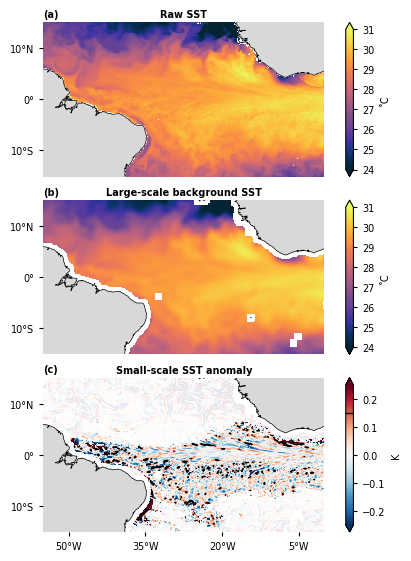

In [ ]:
# User settings of spatiotemporal plotting area
lat_slice = slice(-15, 15)
lon_slice = slice(-55, 0)
time_index = 1
threshold = config['feature']['threshold']

# select data for plotting
dset_plot = dset.isel(time=time_index).sel(lat=lat_slice, lon=lon_slice)
rainbelt_plot = rainbelt.isel(time=time_index-1).sel(lat=lat_slice, lon=lon_slice)

# ------------------------------------------------------------------------------
# plotting
_, axs = hffig.init_subfig(
    style=('ams', 'twothird_page'), asprat=(12, 15), nrow=3, ncol=1,
    sharex=True, proj=ccrs.Mercator(central_longitude=-160),
    )

# filled contour plots
(dset_plot['ts']-273.15).plot(
    ax=axs[0, 0], vmin=24, vmax=31, cmap=cmocean.cm.thermal, extend='both',
    cbar_kwargs={'orientation': 'vertical', 'label': '˚C'},
    transform=ccrs.PlateCarree(),
    ) # type: ignore
axs[0, 0].set_title('Raw SST', weight='bold', pad=3.5)

(dset_plot[f'ts_bg']-273.15).plot(
    ax=axs[1, 0], vmin=24, vmax=31, cmap=cmocean.cm.thermal, extend='both',
    cbar_kwargs={'orientation': 'vertical', 'label': '˚C'},
    transform=ccrs.PlateCarree(),
    ) # type: ignore
axs[1, 0].set_title('Large-scale background SST', weight='bold', pad=3.5)

dset_plot[f'ts_ano'].where(~rainbelt_plot).plot(
    ax=axs[2, 0], vmin=-0.25, vmax=0.25, cmap='RdBu_r',
    extend='both', transform=ccrs.PlateCarree(), alpha=0.1, add_colorbar=False
    ) # type: ignore


im = dset_plot[f'ts_ano'].where(rainbelt_plot).plot(
    ax=axs[2, 0], vmin=-0.25, vmax=0.25, cmap='RdBu_r',
    extend='both', transform=ccrs.PlateCarree(),
    cbar_kwargs={'orientation': 'vertical', 'label': 'K'},
    ) # type: ignore
axs[2, 0].set_title('Small-scale SST anomaly', weight='bold', pad=3.5)
cbar = im.colorbar
cbar.ax.axhline(0.15, color='k', linewidth=1)

# overlay contour lines for anomalies
axs[2, 0].contour(
    dset_plot['lon'], dset_plot['lat'], dset_plot[f'ts_ano'].where(rainbelt_plot),
    levels=[threshold], colors='k', transform=ccrs.PlateCarree(), lw=0.6
    )

# make plot nice
for i in range(0, 3):
    axs[i, 0].set_yticks(np.arange(-10, 11, 10), crs=ccrs.PlateCarree())
    axs[i, 0].yaxis.set_major_formatter(tck.LatitudeFormatter())
    axs[i, 0].set_ylabel(None)

    axs[i, 0].coastlines(resolution='50m', linewidth=0.5)
    axs[i, 0].add_feature(cfeature.LAND, facecolor='gray', alpha=0.3)
    for spine in axs[i, 0].spines.values():
        spine.set_visible(False)

axs[2, 0].set_xticks(np.arange(-50, 0, 15), crs=ccrs.PlateCarree())
axs[2, 0].xaxis.set_major_formatter(tck.LongitudeFormatter())
axs[2, 0].set_xlabel(None)

plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figureA1.png')
plt.savefig(str(outpath/outfile), dpi=600)
plt.show()